## Phase 1: Run Linear Probes on Single Datasets: LLaMA-2-7B on nq (3k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_084223-nhdh3ino/files')  # path for mistral-7b on nq (2k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-10erpy23 because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([2.3026, 0.6390, 1.2275,  ..., 0.9404, 0.8979, 2.1640])


In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [5]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.5421) tensor(0.6785)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [6]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [7]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [9]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [10]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

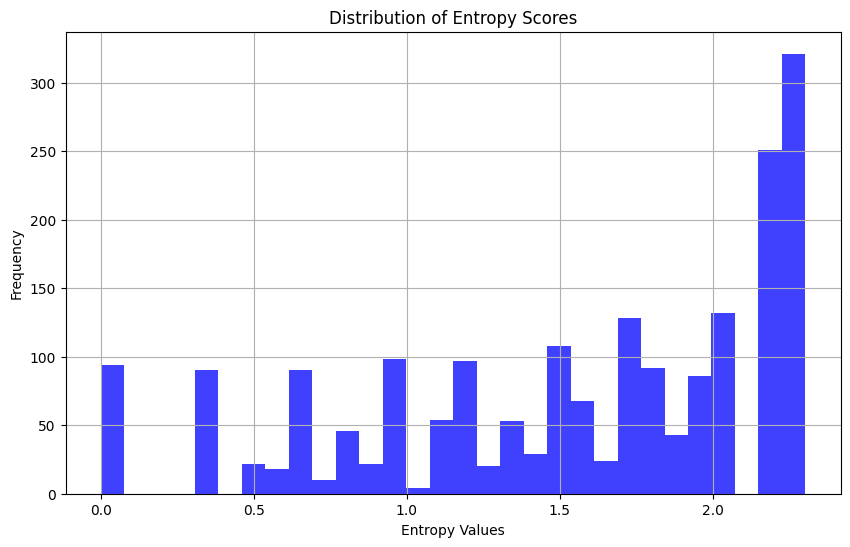

In [11]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.3489892651750504

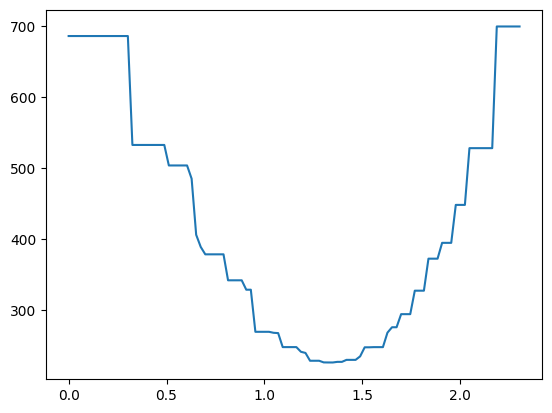

In [12]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [13]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.6655


In [14]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [15]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6833, AUROC: 0.6338
Training Loss: 0.6205, Validation Loss: 0.6143
Test Loss: 0.6558, Test Accuracy: 0.6250, AUROC: 0.5415
Training on Dataset 2/33
Validation Accuracy: 0.6833, AUROC: 0.6744
Training Loss: 0.5965, Validation Loss: 0.6026
Test Loss: 0.6467, Test Accuracy: 0.6250, AUROC: 0.5930
Training on Dataset 3/33
Validation Accuracy: 0.6889, AUROC: 0.6557
Training Loss: 0.5675, Validation Loss: 0.5957
Test Loss: 0.6376, Test Accuracy: 0.6450, AUROC: 0.6346
Training on Dataset 4/33
Validation Accuracy: 0.6889, AUROC: 0.6616
Training Loss: 0.5332, Validation Loss: 0.5895
Test Loss: 0.6315, Test Accuracy: 0.6550, AUROC: 0.6450
Training on Dataset 5/33
Validation Accuracy: 0.6944, AUROC: 0.6810
Training Loss: 0.4962, Validation Loss: 0.5791
Test Loss: 0.6271, Test Accuracy: 0.6700, AUROC: 0.6581
Training on Dataset 6/33
Validation Accuracy: 0.7167, AUROC: 0.7162
Training Loss: 0.4530, Validation Loss: 0.5593
Test Loss: 0.6158, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7806, AUROC: 0.8191
Training Loss: 0.1052, Validation Loss: 0.5811
Test Loss: 0.6452, Test Accuracy: 0.7400, AUROC: 0.7863
Training on Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8012
Training Loss: 0.0870, Validation Loss: 0.6342
Test Loss: 0.6667, Test Accuracy: 0.7200, AUROC: 0.7900
Training on Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7417, AUROC: 0.8123
Training Loss: 0.0641, Validation Loss: 0.6263
Test Loss: 0.7130, Test Accuracy: 0.7000, AUROC: 0.7833
Training on Dataset 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.7976
Training Loss: 0.0410, Validation Loss: 0.7257
Test Loss: 0.7813, Test Accuracy: 0.7150, AUROC: 0.7781
Training on Dataset 22/33
Validation Accuracy: 0.7639, AUROC: 0.7986
Training Loss: 0.0297, Validation Loss: 0.7382
Test Loss: 0.8130, Test Accuracy: 0.7300, AUROC: 0.7795
Training on Dataset 23/33
Validation Accuracy: 0.7528, AUROC: 0.7841
Training Loss: 0.0229, Validation Loss: 0.7960
Test Loss: 0.8549, Test Accuracy: 0.7200, AUROC: 0.7637
Training on Dataset 24/33
Validation Accuracy: 0.7361, AUROC: 0.7849
Training Loss: 0.0195, Validation Loss: 0.7876
Test Loss: 0.7545, Test Accuracy: 0.7400, AUROC: 0.7959
Training on Dataset 25/33
Validation Accuracy: 0.7472, AUROC: 0.7848
Training Loss: 0.0161, Validation Loss: 0.7892
Test Loss: 0.7599, Test Accuracy: 0.7450, AUROC: 0.7946
Training on Dataset 26/33
Validation Accuracy: 0.7778, AUROC: 0.7980
Training Loss: 0.0137, Validation Loss: 0.7613
Test Loss: 0.8263, Test Accuracy: 0.7400, AUROC: 0

In [16]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.8076 at layer 28


In [17]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [18]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [28]
Validation Accuracy: 0.7639, AUROC: 0.8013
Training Loss: 0.0109, Validation Loss: 0.7770
Test Loss: 0.7788, Test Accuracy: 0.7600, AUROC: 0.8076
Training on top-2 Datasets indexed [28, 16]
Validation Accuracy: 0.7694, AUROC: 0.8066
Training Loss: 0.0101, Validation Loss: 0.7605
Test Loss: 0.7686, Test Accuracy: 0.7650, AUROC: 0.8127
Training on top-3 Datasets indexed [28, 16, 29]
Validation Accuracy: 0.7528, AUROC: 0.7979
Training Loss: 0.0054, Validation Loss: 0.8445
Test Loss: 0.8362, Test Accuracy: 0.7550, AUROC: 0.8115
Training on top-4 Datasets indexed [28, 16, 29, 24]
Validation Accuracy: 0.7500, AUROC: 0.8001
Training Loss: 0.0046, Validation Loss: 0.8524
Test Loss: 0.8402, Test Accuracy: 0.7400, AUROC: 0.8127
Training on top-5 Datasets indexed [28, 16, 29, 24, 15]
Validation Accuracy: 0.7583, AUROC: 0.8017
Training Loss: 0.0045, Validation Loss: 0.8505
Test Loss: 0.8475, Test Accuracy: 0.7550, AUROC: 0.8145
Training on top-6 Datasets ind

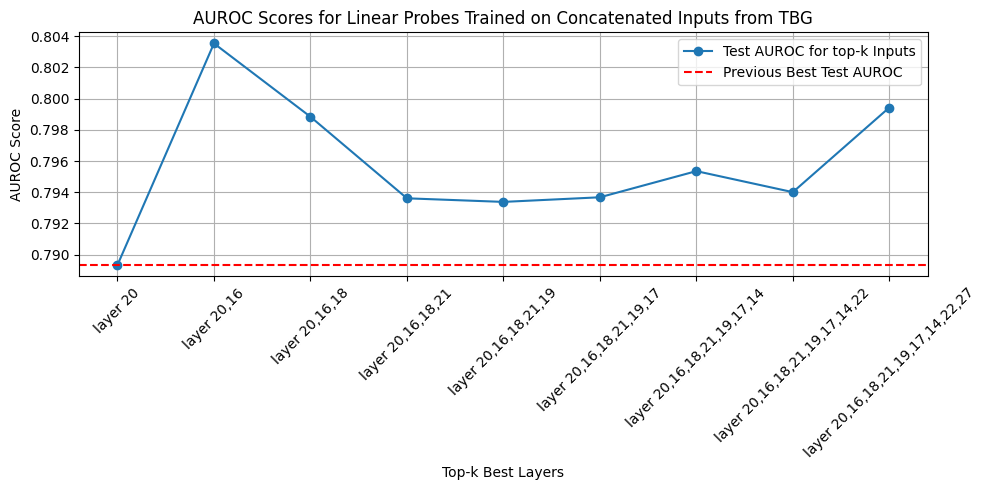

0.8035373791833783


In [53]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')
print(max(topktblr_test_aucs.values()))

### Explore Second Last generated Token (SLT)


In [19]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [20]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [21]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [18]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
# slt_layered_datasets = slt_layered_datasets[1:]

In [24]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [25]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6833, AUROC: 0.5000
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6654, Test Accuracy: 0.6250, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.6833, AUROC: 0.4712
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6654, Test Accuracy: 0.6250, AUROC: 0.4167
Training on Dataset 3/33
Validation Accuracy: 0.6833, AUROC: 0.4680
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6654, Test Accuracy: 0.6250, AUROC: 0.4595
Training on Dataset 4/33
Validation Accuracy: 0.6833, AUROC: 0.6787
Training Loss: 0.6297, Validation Loss: 0.6168
Test Loss: 0.6604, Test Accuracy: 0.6250, AUROC: 0.6325
Training on Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6983
Training Loss: 0.6191, Validation Loss: 0.6058
Test Loss: 0.6497, Test Accuracy: 0.6250, AUROC: 0.6781
Training on Dataset 6/33
Validation Accuracy: 0.6833, AUROC: 0.7207
Training Loss: 0.5988, Validation Loss: 0.5870
Test Loss: 0.6307, Test Accura

In [26]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8219 at layer 15


In [27]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [15]
Validation Accuracy: 0.7722, AUROC: 0.8461
Training Loss: 0.2498, Validation Loss: 0.4440
Test Loss: 0.5098, Test Accuracy: 0.7650, AUROC: 0.8219
Training on top-2 Datasets indexed [15, 16]
Validation Accuracy: 0.7861, AUROC: 0.8504
Training Loss: 0.1765, Validation Loss: 0.4511
Test Loss: 0.5474, Test Accuracy: 0.7500, AUROC: 0.8108
Training on top-3 Datasets indexed [15, 16, 17]
Validation Accuracy: 0.7917, AUROC: 0.8403
Training Loss: 0.1143, Validation Loss: 0.4990
Test Loss: 0.5833, Test Accuracy: 0.7400, AUROC: 0.8108
Training on top-4 Datasets indexed [15, 16, 17, 18]
Validation Accuracy: 0.7917, AUROC: 0.8299
Training Loss: 0.0757, Validation Loss: 0.5507
Test Loss: 0.6131, Test Accuracy: 0.7550, AUROC: 0.8141
Training on top-5 Datasets indexed [15, 16, 17, 18, 14]
Validation Accuracy: 0.8028, AUROC: 0.8301
Training Loss: 0.0712, Validation Loss: 0.5515
Test Loss: 0.6161, Test Accuracy: 0.7550, AUROC: 0.8126
Training on top-6 Datasets ind

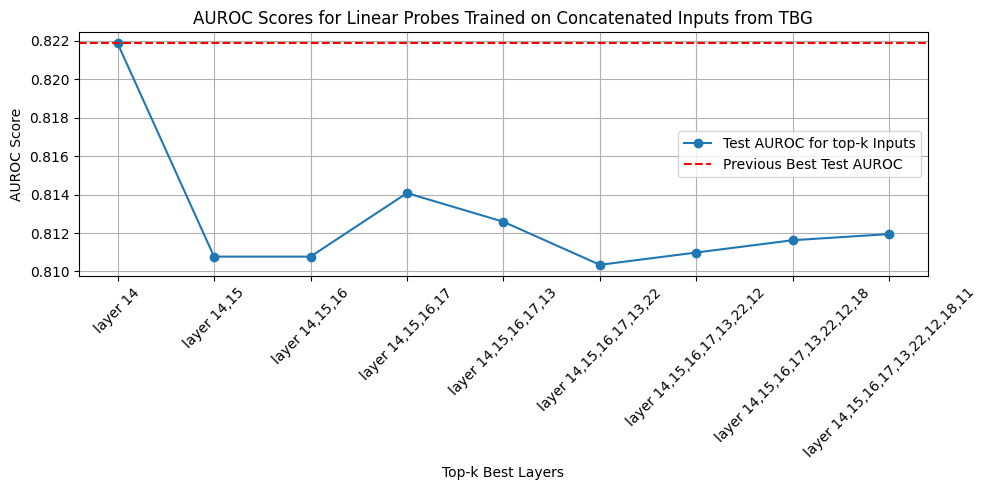

0.8218666666666666


In [28]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'TBG')
print(max(topksblr_test_aucs.values()))

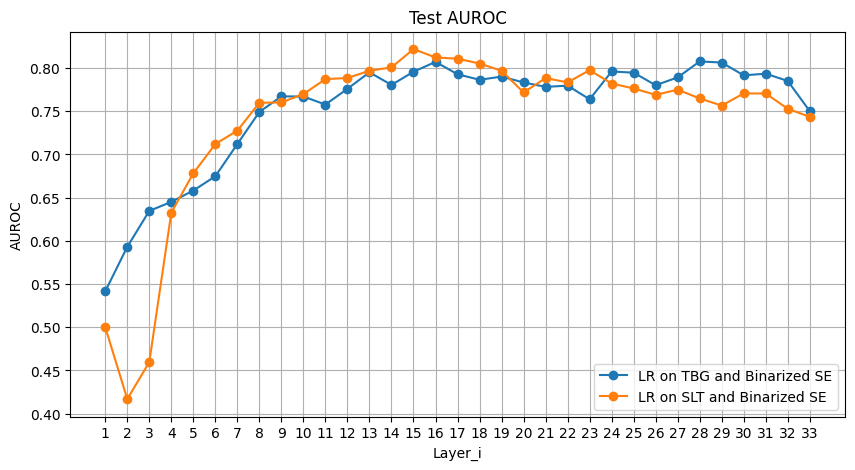

TBG: max AUROC for LR trained and tested on Binarized SE: 0.8076 at 28 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.8219 at 15 layer


In [29]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [30]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])


In [31]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [32]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.6850


In [33]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.7306, AUROC: 0.5672
Training Loss: 0.5862, Validation Loss: 0.5823
Test Loss: 0.6152, Test Accuracy: 0.6850, AUROC: 0.6350
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.7306, AUROC: 0.6007
Training Loss: 0.5716, Validation Loss: 0.5787
Test Loss: 0.6032, Test Accuracy: 0.6850, AUROC: 0.6759
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.7306, AUROC: 0.6006
Training Loss: 0.5460, Validation Loss: 0.5760
Test Loss: 0.5943, Test Accuracy: 0.6850, AUROC: 0.6772
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.7306, AUROC: 0.5916
Training Loss: 0.5130, Validation Loss: 0.5749
Test Loss: 0.5865, Test Accuracy: 0.6850, AUROC: 0.6851
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.7306, AUROC: 0.6023
Training Loss: 0.4785, Validation Loss: 0.5706
Test Loss: 0.5804, Test Accuracy: 0.6850, AUROC: 0.6919
Training on TBG-Acc Dataset 6/33
Validation Accuracy: 0.7389, AUROC: 0.6237
Training Loss: 0.4440, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7083, AUROC: 0.6998
Training Loss: 0.1285, Validation Loss: 0.6406
Test Loss: 0.6930, Test Accuracy: 0.7200, AUROC: 0.7204
Training on TBG-Acc Dataset 19/33
Validation Accuracy: 0.7111, AUROC: 0.6965
Training Loss: 0.1074, Validation Loss: 0.6870
Test Loss: 0.7163, Test Accuracy: 0.7500, AUROC: 0.7208
Training on TBG-Acc Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7194, AUROC: 0.6980
Training Loss: 0.0763, Validation Loss: 0.7258
Test Loss: 0.7679, Test Accuracy: 0.7300, AUROC: 0.7175
Training on TBG-Acc Dataset 21/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.6826
Training Loss: 0.0266, Validation Loss: 0.9048
Test Loss: 0.9739, Test Accuracy: 0.7450, AUROC: 0.6953
Training on TBG-Acc Dataset 24/33
Validation Accuracy: 0.7278, AUROC: 0.6797
Training Loss: 0.0223, Validation Loss: 0.9064
Test Loss: 0.9775, Test Accuracy: 0.7400, AUROC: 0.7055
Training on TBG-Acc Dataset 25/33
Validation Accuracy: 0.7306, AUROC: 0.6932
Training Loss: 0.0189, Validation Loss: 0.8970
Test Loss: 0.9802, Test Accuracy: 0.7250, AUROC: 0.7076
Training on TBG-Acc Dataset 26/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.6877
Training Loss: 0.0162, Validation Loss: 0.9277
Test Loss: 1.0569, Test Accuracy: 0.7250, AUROC: 0.6788
Training on TBG-Acc Dataset 27/33
Validation Accuracy: 0.7139, AUROC: 0.6905
Training Loss: 0.0145, Validation Loss: 0.9392
Test Loss: 1.0536, Test Accuracy: 0.7250, AUROC: 0.6884
Training on TBG-Acc Dataset 28/33
Validation Accuracy: 0.7139, AUROC: 0.6831
Training Loss: 0.0129, Validation Loss: 0.9675
Test Loss: 1.0331, Test Accuracy: 0.7000, AUROC: 0.6905
Training on TBG-Acc Dataset 29/33
Validation Accuracy: 0.7194, AUROC: 0.6772
Training Loss: 0.0118, Validation Loss: 0.9964
Test Loss: 1.0438, Test Accuracy: 0.6950, AUROC: 0.6975
Training on TBG-Acc Dataset 30/33
Validation Accuracy: 0.6889, AUROC: 0.6743
Training Loss: 0.0100, Validation Loss: 1.0454
Test Loss: 1.1636, Test Accuracy: 0.7100, AUROC: 0.6744
Training on TBG-Acc Dataset 31/33
Validation Accuracy: 0.7000, AUROC: 0.6921
Training Loss: 0.0090, Validation Loss: 1.0221
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


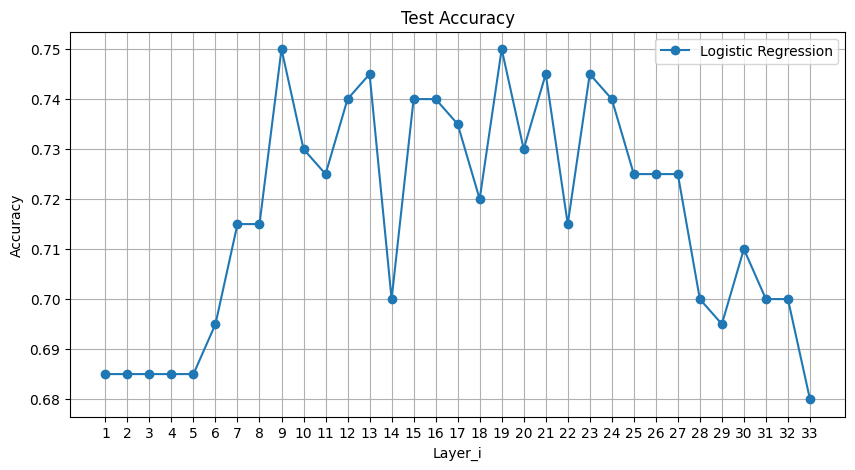

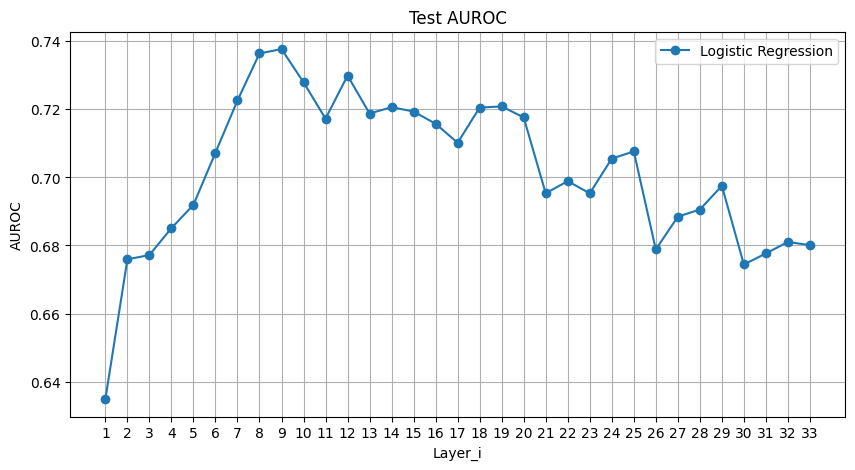

In [36]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [35]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.7376 at layer 9


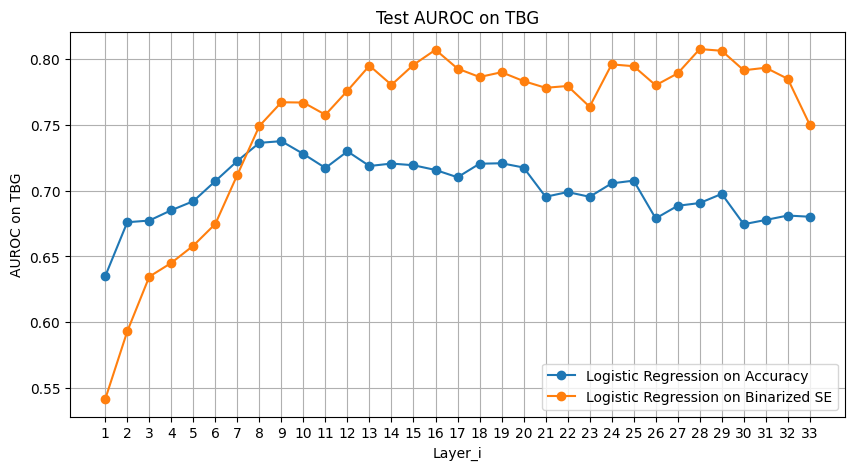

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7376 at 9 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8076 at 28 layer


In [37]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [38]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [39]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.7306, AUROC: 0.5000
Training Loss: 0.5954, Validation Loss: 0.5831
Test Loss: 0.6256, Test Accuracy: 0.6850, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.7306, AUROC: 0.6046
Training Loss: 0.5953, Validation Loss: 0.5830
Test Loss: 0.6255, Test Accuracy: 0.6850, AUROC: 0.5808
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.7306, AUROC: 0.5864
Training Loss: 0.5946, Validation Loss: 0.5824
Test Loss: 0.6252, Test Accuracy: 0.6850, AUROC: 0.5498
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.7306, AUROC: 0.6330
Training Loss: 0.5912, Validation Loss: 0.5792
Test Loss: 0.6214, Test Accuracy: 0.6850, AUROC: 0.6122
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.7306, AUROC: 0.6549
Training Loss: 0.5853, Validation Loss: 0.5732
Test Loss: 0.6143, Test Accuracy: 0.6850, AUROC: 0.6531
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.7306, AUROC: 0.6770
Training Loss: 0.5701, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


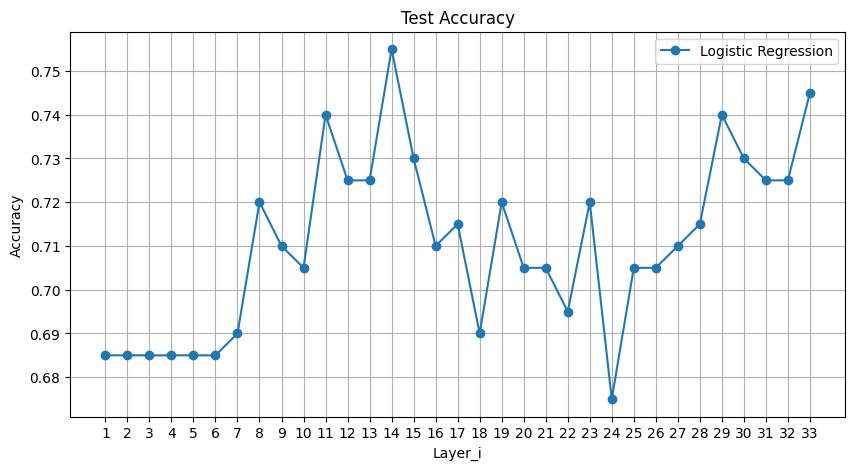

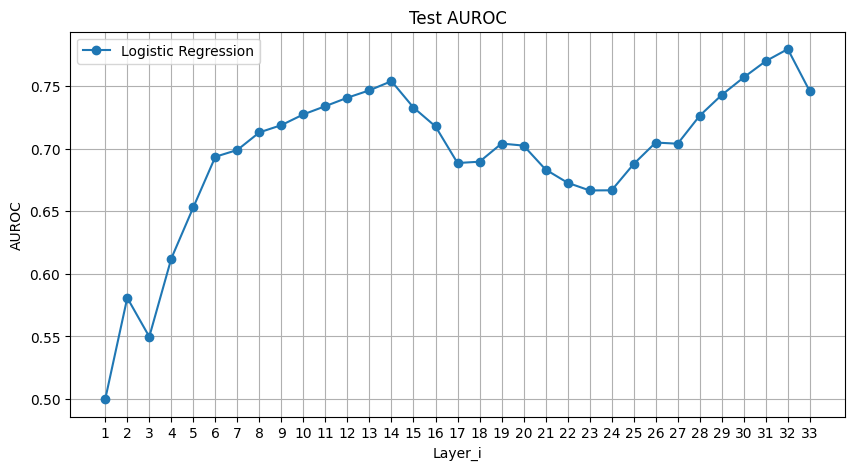

In [40]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [43]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7794 at layer 32


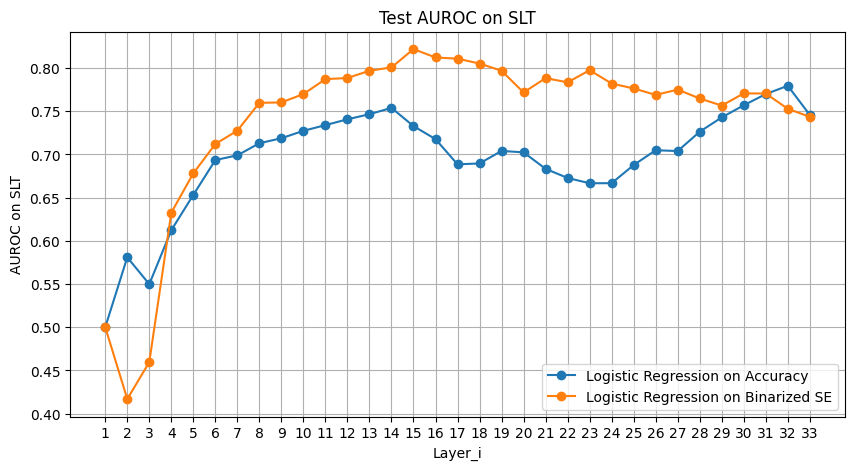

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7794 at 32 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8219 at 15 layer


In [44]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

#### Compare TBG and SLT at predicting Acc

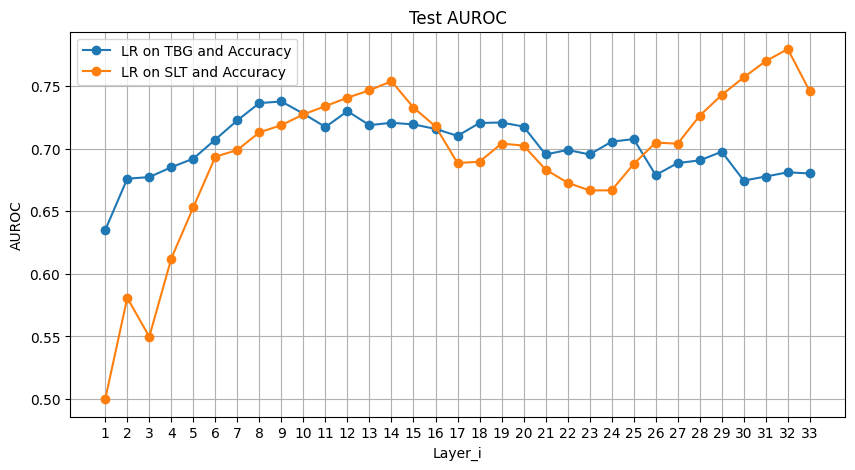

TBG: max AUROC for LR trained and tested on Accuracy: 0.7376 at 9 layer
SLT: max AUROC for LR trained and tested on Accuracy: 0.7794 at 32 layer


In [45]:
plot_1d_metrics([talr_test_aucs, salr_test_aucs], ['LR on TBG and Accuracy', 'LR on SLT and Accuracy'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [46]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [47]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.6833, AUROC: 0.6338
Training Loss: 0.6205, Validation Loss: 0.6143
Test Loss: 0.6116, Test Accuracy: 0.6850, AUROC: 0.5955
Training on TBG Dataset 2/33
Validation Accuracy: 0.6833, AUROC: 0.6744
Training Loss: 0.5965, Validation Loss: 0.6026
Test Loss: 0.6004, Test Accuracy: 0.6850, AUROC: 0.6392
Training on TBG Dataset 3/33
Validation Accuracy: 0.6889, AUROC: 0.6557
Training Loss: 0.5675, Validation Loss: 0.5957
Test Loss: 0.5914, Test Accuracy: 0.6950, AUROC: 0.6672
Training on TBG Dataset 4/33
Validation Accuracy: 0.6889, AUROC: 0.6616
Training Loss: 0.5332, Validation Loss: 0.5895
Test Loss: 0.5837, Test Accuracy: 0.6850, AUROC: 0.6758
Training on TBG Dataset 5/33
Validation Accuracy: 0.6944, AUROC: 0.6810
Training Loss: 0.4962, Validation Loss: 0.5791
Test Loss: 0.5747, Test Accuracy: 0.7000, AUROC: 0.6900
Training on TBG Dataset 6/33
Validation Accuracy: 0.7167, AUROC: 0.7162
Training Loss: 0.4530, Validation Loss: 0.5593
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7806, AUROC: 0.8191
Training Loss: 0.1052, Validation Loss: 0.5811
Test Loss: 0.6357, Test Accuracy: 0.7500, AUROC: 0.7573
Training on TBG Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8012
Training Loss: 0.0870, Validation Loss: 0.6342
Test Loss: 0.6080, Test Accuracy: 0.7300, AUROC: 0.7770
Training on TBG Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7417, AUROC: 0.8123
Training Loss: 0.0641, Validation Loss: 0.6263
Test Loss: 0.6961, Test Accuracy: 0.7200, AUROC: 0.7504
Training on TBG Dataset 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.7976
Training Loss: 0.0410, Validation Loss: 0.7257
Test Loss: 0.8159, Test Accuracy: 0.6750, AUROC: 0.7281
Training on TBG Dataset 22/33
Validation Accuracy: 0.7639, AUROC: 0.7986
Training Loss: 0.0297, Validation Loss: 0.7382
Test Loss: 0.8490, Test Accuracy: 0.6900, AUROC: 0.7334
Training on TBG Dataset 23/33
Validation Accuracy: 0.7528, AUROC: 0.7841
Training Loss: 0.0229, Validation Loss: 0.7960
Test Loss: 0.8086, Test Accuracy: 0.6900, AUROC: 0.7485
Training on TBG Dataset 24/33
Validation Accuracy: 0.7361, AUROC: 0.7849
Training Loss: 0.0195, Validation Loss: 0.7876
Test Loss: 0.8110, Test Accuracy: 0.7100, AUROC: 0.7481
Training on TBG Dataset 25/33
Validation Accuracy: 0.7472, AUROC: 0.7848
Training Loss: 0.0161, Validation Loss: 0.7892
Test Loss: 0.8084, Test Accuracy: 0.6950, AUROC: 0.7439
Training on TBG Dataset 26/33
Validation Accuracy: 0.7778, AUROC: 0.7980
Training Loss: 0.0137, Validation Loss: 0.7613
Test Loss: 0.8054, Test Accura

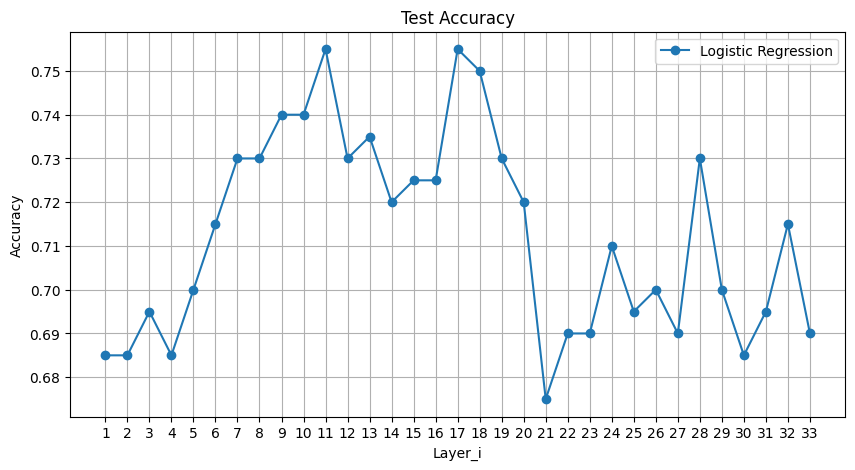

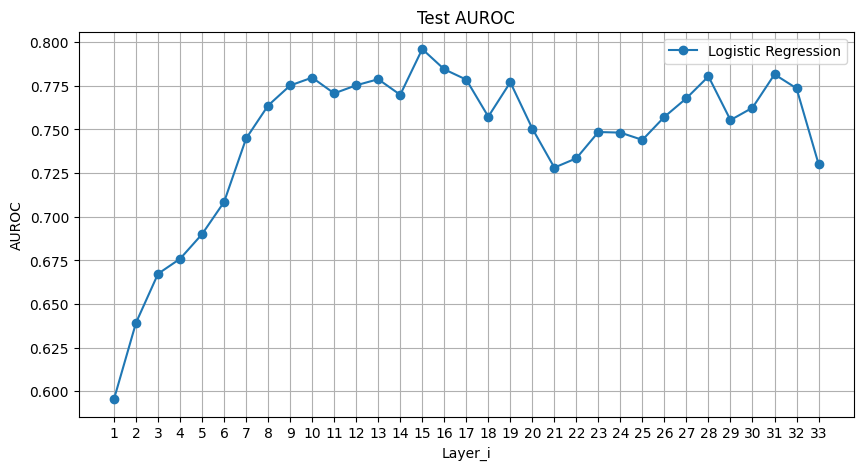

In [48]:
plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

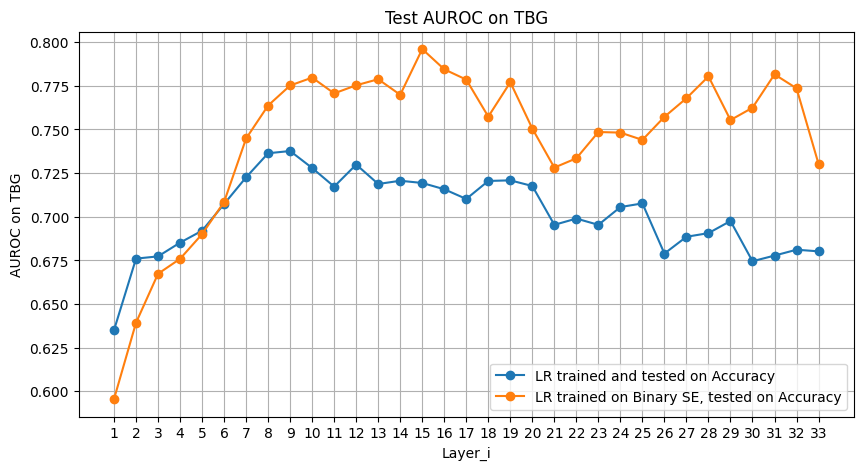

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7376 at 9 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7960 at 15 layer


In [50]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [51]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [52]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.6833, AUROC: 0.5000
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6238, Test Accuracy: 0.6850, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.6833, AUROC: 0.4712
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6238, Test Accuracy: 0.6850, AUROC: 0.4479
Training on SLT Dataset 3/33
Validation Accuracy: 0.6833, AUROC: 0.4680
Training Loss: 0.6365, Validation Loss: 0.6250
Test Loss: 0.6238, Test Accuracy: 0.6850, AUROC: 0.5043
Training on SLT Dataset 4/33
Validation Accuracy: 0.6833, AUROC: 0.6787
Training Loss: 0.6297, Validation Loss: 0.6168
Test Loss: 0.6196, Test Accuracy: 0.6850, AUROC: 0.6185
Training on SLT Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6983
Training Loss: 0.6191, Validation Loss: 0.6058
Test Loss: 0.6117, Test Accuracy: 0.6850, AUROC: 0.6525
Training on SLT Dataset 6/33
Validation Accuracy: 0.6833, AUROC: 0.7207
Training Loss: 0.5988, Validation Loss: 0.5870
Test L

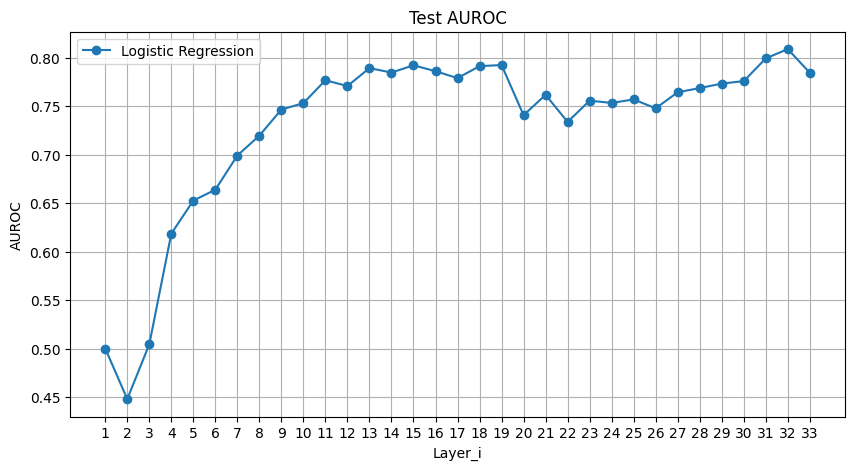

In [53]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

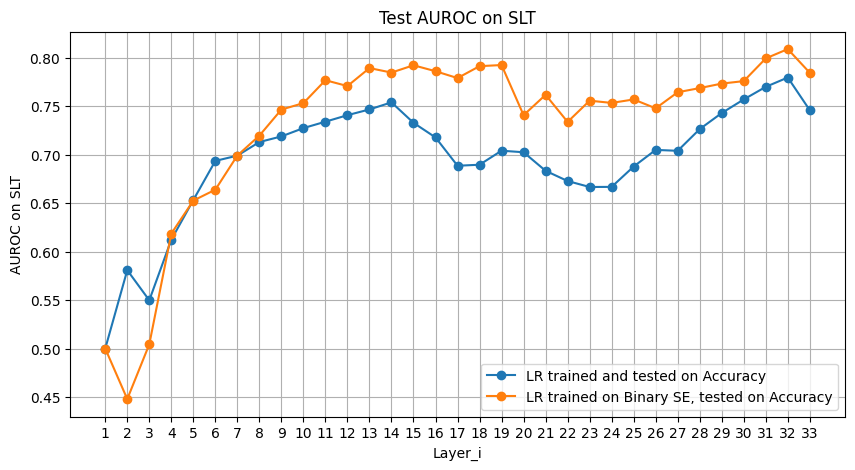

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7794 at 32 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8087 at 32 layer


In [54]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")